In [ ]:

# Import Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# Load Dataset
dataset = load_dataset('Sumedchakma/jobs_record')
df = dataset['train'].to_pandas()

#---------------
# Data Cleaning
#---------------

# Convert job_posted_date to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from string to list
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [20]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & 
              (df['job_country'] == 'United States')].copy()

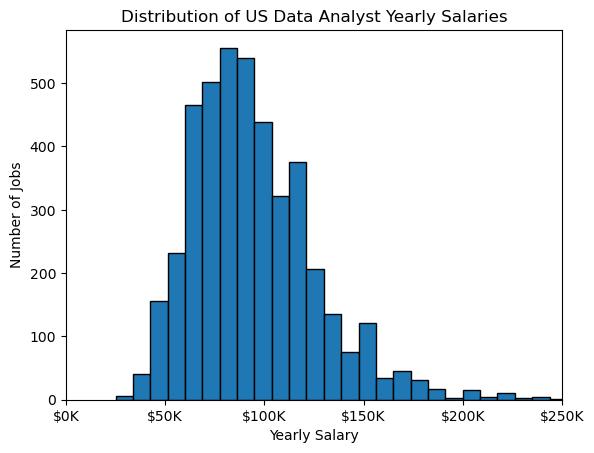

In [22]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')

plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.title('Distribution of US Data Analyst Yearly Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')

plt.show()